In [1]:
%pip install cartopy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
from pathlib import Path
from pyspark.sql import SparkSession
##import h5py
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, PCA
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
import time
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator


Matplotlib created a temporary cache directory at /scratch/dmoncivais/job_47467917/matplotlib-zq8_ai1_ because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
out_dir = Path(f"/expanse/lustre/projects/uci157/{os.environ['USER']}/stead")
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Downloading to: {out_dir}")

In [4]:
path = kagglehub.dataset_download("isevilla/stanford-earthquake-dataset-stead", output_dir = str(out_dir))

print("Path to dataset files:", path)

Path to dataset files: /expanse/lustre/projects/uci157/dmoncivais/stead


In [5]:
spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "9g") \
    .config('spark.executor.instances', 15) \
    .getOrCreate()

In [6]:
df = spark.read.csv(f"{out_dir}/merge.csv", header = True, inferSchema = True)
print(type(df))

<class 'pyspark.sql.dataframe.DataFrame'>


How many observations?

In [7]:
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 1268314
Columns: 35


In [8]:
# show schema + a few rows
df.printSchema()
df.show(5, truncate=60)

root
 |-- network_code: string (nullable = true)
 |-- receiver_code: string (nullable = true)
 |-- receiver_type: string (nullable = true)
 |-- receiver_latitude: double (nullable = true)
 |-- receiver_longitude: string (nullable = true)
 |-- receiver_elevation_m: string (nullable = true)
 |-- p_arrival_sample: string (nullable = true)
 |-- p_status: string (nullable = true)
 |-- p_weight: string (nullable = true)
 |-- p_travel_sec: double (nullable = true)
 |-- s_arrival_sample: double (nullable = true)
 |-- s_status: string (nullable = true)
 |-- s_weight: double (nullable = true)
 |-- source_id: string (nullable = true)
 |-- source_origin_time: timestamp (nullable = true)
 |-- source_origin_uncertainty_sec: string (nullable = true)
 |-- source_latitude: double (nullable = true)
 |-- source_longitude: double (nullable = true)
 |-- source_error_sec: string (nullable = true)
 |-- source_gap_deg: string (nullable = true)
 |-- source_horizontal_uncertainty_km: string (nullable = true)
 |

Describe Columns

In [9]:
df.describe().show(truncate=False)

+-------+----------------------------------------------+-----------------+------------------+------------------+-------------------------------------+--------------------+-----------------+---------+------------------------+-----------------+-----------------+---------+-------------------+--------------------+-----------------------------+-----------------+-------------------+----------------+--------------+--------------------------------+------------------+---------------------------+------------------+---------------------+-----------------------+--------------------------------+-------------------+------------------+------------------+-------------------------------------+---------------+----------------+-------------------------+
|summary|network_code                                  |receiver_code    |receiver_type     |receiver_latitude |receiver_longitude                   |receiver_elevation_m|p_arrival_sample |p_status |p_weight                |p_travel_sec     |s_arrival_sam

Categorical and Continuous columns

In [10]:
dtypes = dict(df.dtypes)

cat_cols = [c for c, t in df.dtypes if t == "string"]
num_cols = [c for c, t in df.dtypes if t != "string"]

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

# target column
target_col = "trace_category" if "trace_category" in df.columns else None
print("Target column:", target_col)

# target distribution
if target_col:
    df.groupBy(target_col).count().orderBy(F.desc("count")).show(truncate=False)

# Categorical columns
for c in cat_cols:
    print(f"\n=== {c} ===")
    df.select(c).distinct().count() # just to run it
    print("Distinct:", df.select(c).distinct().count())
    df.groupBy(c).count().orderBy(F.desc("count")).show(10, truncate=False)

Categorical columns: ['network_code', 'receiver_code', 'receiver_type', 'receiver_longitude', 'receiver_elevation_m', 'p_arrival_sample', 'p_status', 'p_weight', 's_status', 'source_id', 'source_origin_uncertainty_sec', 'source_error_sec', 'source_gap_deg', 'source_horizontal_uncertainty_km', 'source_depth_km', 'source_depth_uncertainty_km', 'source_magnitude_type', 'source_magnitude_author', 'source_mechanism_strike_dip_rake', 'snr_db', 'coda_end_sample', 'trace_category', 'trace_name']
Numeric columns: ['receiver_latitude', 'p_travel_sec', 's_arrival_sample', 's_weight', 'source_origin_time', 'source_latitude', 'source_longitude', 'source_magnitude', 'source_distance_deg', 'source_distance_km', 'back_azimuth_deg', 'trace_start_time']
Target column: trace_category
+----------------+-------+
|trace_category  |count  |
+----------------+-------+
|earthquake_local|1027574|
|noise           |235426 |
|NULL            |5314   |
+----------------+-------+


=== network_code ===
Distinct: 10

Missing values per column and Duplicates

In [11]:
missing_exprs = []
for c, t in df.dtypes:
    if t in ["double", "float", "int", "bigint", "smallint", "tinyint", "decimal", "long", "short"]:
        missing_exprs.append(F.sum(F.when(F.col(c).isNull() | F.isnan(F.col(c)), 1).otherwise(0)).alias(c))
    else:
        missing_exprs.append(F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c))

df.select(missing_exprs).show(truncate=False)

# duplicate rows
total_rows = df.count()
unique_rows = df.dropDuplicates().count()
print("Duplicate rows:", total_rows - unique_rows)

+------------+-------------+-------------+-----------------+------------------+--------------------+----------------+--------+--------+------------+----------------+--------+--------+---------+------------------+-----------------------------+---------------+----------------+----------------+--------------+--------------------------------+---------------+---------------------------+----------------+---------------------+-----------------------+--------------------------------+-------------------+------------------+----------------+------+---------------+----------------+--------------+----------+
|network_code|receiver_code|receiver_type|receiver_latitude|receiver_longitude|receiver_elevation_m|p_arrival_sample|p_status|p_weight|p_travel_sec|s_arrival_sample|s_status|s_weight|source_id|source_origin_time|source_origin_uncertainty_sec|source_latitude|source_longitude|source_error_sec|source_gap_deg|source_horizontal_uncertainty_km|source_depth_km|source_depth_uncertainty_km|source_magnit

In the next block of code there will basic information about the dataset.

In [12]:
print(f"Number of rows: {df.count()}\n")

print("Description of the data set:")
df.describe().show()

print("Data frame schema:")
df.printSchema()

print(f"Top 100 receivers based on count of readings: (receiver_code | count)")
i = 0
for row in df.groupBy('receiver_code').count().sort('count', ascending=False).collect():
    print(f"{row['receiver_code']} | {row['count']}")
    i += 1
    if i == 100:
        break

print(f"\nTotal of unique values:\n\tUnique number of network codes:{df.select('network_code').distinct().count()}\n\tUnique number of receiver_code:{df.select('receiver_code').distinct().count()}\n\tUnique number of receiver_type:{df.select('receiver_type').distinct().count()}")

Number of rows: 1268314

Description of the data set:
+-------+--------------------+-----------------+------------------+------------------+--------------------+--------------------+-----------------+---------+--------------------+-----------------+-----------------+---------+-------------------+--------------------+-----------------------------+-----------------+-------------------+----------------+--------------+--------------------------------+------------------+---------------------------+------------------+---------------------+-----------------------+--------------------------------+-------------------+------------------+------------------+--------------------+---------------+----------------+--------------------+
|summary|        network_code|    receiver_code|     receiver_type| receiver_latitude|  receiver_longitude|receiver_elevation_m| p_arrival_sample| p_status|            p_weight|     p_travel_sec| s_arrival_sample| s_status|           s_weight|           source_id|source

In [13]:
coordinates = df.select("receiver_latitude", "receiver_longitude")\
              .rdd.map(lambda x: (x[0], x[1]))
coords = coordinates.collect()

latitudes = []
longitudes = []
i = 0
for row in coords:
    try:
        longitudes.append(float(row[1]))
        latitudes.append(float(row[0]))
    except Exception as e:
        continue

In [14]:
len(longitudes), len(latitudes)

(1265657, 1265657)

In this map, we can see how the stations are distributed around the world. This helps us understand why we have so many data entries in our dataset and gives us insight into how some countries are more research-focused and therefore more prone to generating relevant earthquake data. For example, countries such as Russia, Brazil, Cameroon, India, and Sudan either do not experience earthquakes frequently enough to justify extensive study, or they may not prioritize earthquake monitoring. On the other end of the spectrum, there are countries like the USA, Mexico, Chile, and the UK, where tremors are more frequent and there is greater interest in studying them.

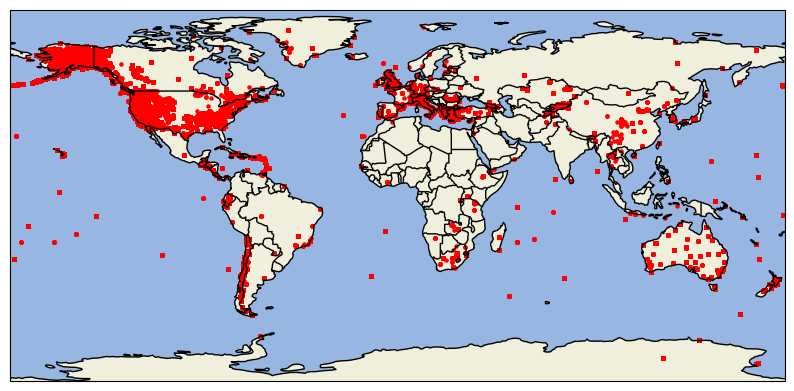

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

ax.scatter(longitudes, latitudes,
           s=5,
           transform=ccrs.PlateCarree(),
           color = 'red'
          )

plt.show()

This project uses a ~100GB dataset, so all preprocessing will be performed in Spark using multiple CPUs.

### Handling Missing Values

**Assessment of missingness**
- For the bulk of our data, there is very little missing data. However, there are some exceptions. For the columns that we do have missing data, we will determine whether or not the data is missing at random or not. This is important to determine whether we can filter this out or not without adding bias to our analysis.

**Strategies (by feature type)**
- **Numeric fields**
  - If missing rate is very low → drop rows with nulls in critical columns.
  - If missingness is spatially/temporally structured, we will look into group-wise imputation (to get the average numbers based on several features) in order to prevent bias being added to the analysis.
- **Categorical fields**
  - Replace nulls with "Unknown" and treat as a legitimate category. However, based on our inital analysis, this does not appear to be an issue.
- **Time-series gaps**
  - For station-level features that should evolve smoothly, consider forward-fill using Spark window functions. This would be the case if a station might have had interuptions with their data.

**Spark operations to potentially use**
- `F.when(F.col(c).isNull(), 1)` (measure missingness)
- `na.drop(subset=[])`
- `na.fill({})`
- `Window.partitionBy().orderBy()` 

### Handling Data Imbalance

There is a heavy imbalance as for the vast majority of time, there is no earthquake.

- I will compute the class distribution and confirm imbalance severity.
- Mitigation options (chosen based on model and evaluation results):
  - **Class weights** (preferred when supported by the estimator)
  - We can downsample the majority class or oversample minority class using Spark sampling, depending on which is better for our accuracy.
  - We will need to adjust the decision threshold and focus on precision/recall metrics rather than accuracy

**Spark operations planned**
- `groupBy(label).count()` (measure imbalance)
- `sampleBy()` (stratified sampling)
- `withColumn("weight", ...)` (add class weights)

### Transformations (scaling, encoding, feature engineering)

To scale the numbers sufficiently for analysis:
  - `StandardScaler` (z-score)
  - `MinMaxScaler` (if StandardScalar is insufficient)

**Encoding**
- For categorical variables (if needed):
  - `StringIndexer` to convert categories to indices
  - `OneHotEncoder` to avoid unintended ordinal relationships

**Feature Engineering (domain-specific for seismic data)**
- **Temporal features** extracted from event timestamp:
  - hour-of-day, day-of-week, month/season, year
- **Correct corrdinates**
  - The corrdinate data includes depth data, so we will need to clean it and potentially separate into separate columns (between depth and actual GPS coordiates)
- **Station/region aggregation features**:
  - event counts per station/region per time window
  - mean/median magnitude per window
- **Spatial features**:
  - spatial binning via coordiates and using region IDs
- **Transforming heavy-tailed variables**:
  - consider log transforms for energy-like measures or skewed sensor metrics

**Leakage prevention (between train and test data)**
- Any features computed using time windows will be constructed using past-only information relative to the prediction timestamp.
- Train/test splitting will be time-aware when appropriate (e.g., split by date)
    -  This should prevent future information from leaking into training.

**Spark operations planned**
- `withColumn()` and built-in time functions (`year`, `month`, `dayofweek`, `hour`)
- `groupBy().agg()` for aggregations
- `Window` functions for lags/rolling features (`lag`, `avg`, `sum`)

### Spark Operations and Performance Considerations

Because the dataset is ~100GB, preprocessing will be optimized for distributed execution:
- Use column pruning (`select`) and filter early (`filter`) to reduce data volume.
  - There will be lots of opportunity for data pruning as for the vast majority of the time there is no earthquakes, so we will be able to truncate the data selectively.
- `repartition()` can be used strategically to improve parallelism, enabling us to be the most efficient with this giant dataset.
- Avoid `collect()` except on small summaries (e.g., counts, small samples) as it is very time consuming.
- Store intermediate outputs in Parquet for efficient re-use (keeping it in memory for minimal recall time)

**Core Spark functions to be used**
- DataFrame ops: `select`, `filter`, `withColumn`, `drop`, `groupBy`, `agg`, `join`
- Missingness tools: `na.fill`, `na.drop`
- Time/rolling: `Window`, `lag`, `lead`, rolling aggregates
- Others: `StringIndexer`, `OneHotEncoder`, `VectorAssembler`, `StandardScaler`, `Pipeline`

## Milestone 3: Preprocessing & Model Training

In [16]:
bad_p_status = df.filter(F.col("p_status") == "earthquake_local")
print("Rows with p_status = 'earthquake_local':", bad_p_status.count())

Rows with p_status = 'earthquake_local': 2657


In [17]:
bad_p_status.select("network_code", "receiver_code", "p_status", "p_weight", "s_status", "trace_category", "source_magnitude").show(10, truncate = False)

+----------------------------------------------+-------------+----------------+-------------------------+--------+--------------+----------------+
|network_code                                  |receiver_code|p_status        |p_weight                 |s_status|trace_category|source_magnitude|
+----------------------------------------------+-------------+----------------+-------------------------+--------+--------------+----------------+
| [ 308.48001099   84.16999817 -161.02000427]]"|0.81         |earthquake_local|109C.TA_20130311165610_EV|NULL    |NULL          |NULL            |
| [ 308.48001099   84.16999817 -161.02000427]]"|0.81         |earthquake_local|109C.TA_20130311165615_EV|NULL    |NULL          |NULL            |
| [ 213.25999451   89.37000275 -111.52999878]]"|1.68         |earthquake_local|109C.TA_20140317132558_EV|NULL    |NULL          |NULL            |
| [262.63000488  61.68999863 -92.76000214]]"   |0.3          |earthquake_local|735A.TA_20111020122441_EV|NULL    |NULL

In [18]:
#We can't use the 2,657 rows with misaligned columns or the 5,314 rows with NULL trace_category (unlabeled) so we are dropping them
print("Before cleaning:", df.count())

df_clean = df.filter(
    (F.col("trace_category").isNotNull()) &
    (F.col("p_status") != "earthquake_local") |(F.col("p_status").isNull()))

print("After cleaning:", df_clean.count())
df_clean.groupBy("trace_category").count().show()

Before cleaning: 1268314
After cleaning: 1263000
+----------------+-------+
|  trace_category|  count|
+----------------+-------+
|           noise| 235426|
|earthquake_local|1027574|
+----------------+-------+



In [19]:
# casting strings to doubles 
cols_to_cast = ["receiver_longitude", "receiver_elevation_m", "p_arrival_sample", "p_weight", 
                "source_origin_uncertainty_sec", "source_error_sec", "source_gap_deg", 
                "source_horizontal_uncertainty_km", "source_depth_km", "source_depth_uncertainty_km", 
                "snr_db", "coda_end_sample" ]

for col_name in cols_to_cast:
    df_clean = df_clean.withColumn(col_name, F.col(col_name).cast("double"))

df_clean.printSchema()

root
 |-- network_code: string (nullable = true)
 |-- receiver_code: string (nullable = true)
 |-- receiver_type: string (nullable = true)
 |-- receiver_latitude: double (nullable = true)
 |-- receiver_longitude: double (nullable = true)
 |-- receiver_elevation_m: double (nullable = true)
 |-- p_arrival_sample: double (nullable = true)
 |-- p_status: string (nullable = true)
 |-- p_weight: double (nullable = true)
 |-- p_travel_sec: double (nullable = true)
 |-- s_arrival_sample: double (nullable = true)
 |-- s_status: string (nullable = true)
 |-- s_weight: double (nullable = true)
 |-- source_id: string (nullable = true)
 |-- source_origin_time: timestamp (nullable = true)
 |-- source_origin_uncertainty_sec: double (nullable = true)
 |-- source_latitude: double (nullable = true)
 |-- source_longitude: double (nullable = true)
 |-- source_error_sec: double (nullable = true)
 |-- source_gap_deg: double (nullable = true)
 |-- source_horizontal_uncertainty_km: double (nullable = true)
 |

In [20]:
# Select only station and signal features for our model
# Dropping magnitude to prevent data leakage
# Our goal is to identify what an earthquake is, and what's just noise, based on the signal
# We are not looking for whether the earthquake metadata exists. So we use:
# - Station features: Where the recording was made
# - Signal features: What the recording looks like

feature_cols = [ 
    # Station features
    "receiver_latitude", "receiver_longitude", "receiver_elevation_m", 
    # Signal features
    "p_arrival_sample", "p_travel_sec", "s_arrival_sample", 
    "s_weight", "snr_db", "coda_end_sample", 
    # Categorical features we'll encode later 
    "receiver_type", "network_code"]

# Keep features + target
df_selected = df_clean.select(feature_cols + ["trace_category"])

print("Selected columns:", df_selected.columns)
print("Row count:", df_selected.count())
df_selected.show(5, truncate=False)


Selected columns: ['receiver_latitude', 'receiver_longitude', 'receiver_elevation_m', 'p_arrival_sample', 'p_travel_sec', 's_arrival_sample', 's_weight', 'snr_db', 'coda_end_sample', 'receiver_type', 'network_code', 'trace_category']
Row count: 1263000
+-----------------+------------------+--------------------+----------------+------------+----------------+--------+------+---------------+-------------+------------+--------------+
|receiver_latitude|receiver_longitude|receiver_elevation_m|p_arrival_sample|p_travel_sec|s_arrival_sample|s_weight|snr_db|coda_end_sample|receiver_type|network_code|trace_category|
+-----------------+------------------+--------------------+----------------+------------+----------------+--------+------+---------------+-------------+------------+--------------+
|32.8889          |-117.1051         |150.0               |NULL            |NULL        |NULL            |NULL    |NULL  |NULL           |HH           |TA          |noise         |
|32.8889          |-117

In [21]:
# Evalutating missingess

missing_counts = df_selected.select([
    F.sum(F.when(F.col(c).isNull(),1).otherwise(0)).alias(c)
    for c in df_selected.columns])
missing_counts.show(truncate=False)

#Show as percentage
total = df_selected.count()
missing_pcts = df_selected.select([
    F.round(F.sum(F.when(F.col(c).isNull(),1).otherwise(0)) / total * 100, 2).alias(c)
    for c in df_selected.columns])

print("Missing percentages:")
missing_pcts.show(truncate = False)

# Noise comes across as null, which indicates it is missing by design and we aren't actually missing information here.

+-----------------+------------------+--------------------+----------------+------------+----------------+--------+-------+---------------+-------------+------------+--------------+
|receiver_latitude|receiver_longitude|receiver_elevation_m|p_arrival_sample|p_travel_sec|s_arrival_sample|s_weight|snr_db |coda_end_sample|receiver_type|network_code|trace_category|
+-----------------+------------------+--------------------+----------------+------------+----------------+--------+-------+---------------+-------------+------------+--------------+
|0                |0                 |0                   |235426          |235426      |235426          |235581  |1263000|1263000        |0            |0           |0             |
+-----------------+------------------+--------------------+----------------+------------+----------------+--------+-------+---------------+-------------+------------+--------------+

Missing percentages:
+-----------------+------------------+--------------------+---------

### Feature Selection & Model Training

In [22]:
# drop columns with all null values
df_selected = df_selected.drop("snr_db", "coda_end_sample") 

# Filling signal nulls with 0 (this makes sense because these rows are very likely to not have waves
signal_cols = ["p_arrival_sample", "p_travel_sec", "s_arrival_sample", "s_weight"] 
df_filled = df_selected.fillna(0, subset=signal_cols)

#Confirming no more nulls
df_filled.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_filled.columns]).show(truncate = False)

+-----------------+------------------+--------------------+----------------+------------+----------------+--------+-------------+------------+--------------+
|receiver_latitude|receiver_longitude|receiver_elevation_m|p_arrival_sample|p_travel_sec|s_arrival_sample|s_weight|receiver_type|network_code|trace_category|
+-----------------+------------------+--------------------+----------------+------------+----------------+--------+-------------+------------+--------------+
|0                |0                 |0                   |0               |0           |0               |0       |0            |0           |0             |
+-----------------+------------------+--------------------+----------------+------------+----------------+--------+-------------+------------+--------------+



In [23]:
# Trying to predict earthquake with just the stations
df_station_only = df_filled.select( "receiver_latitude", "receiver_longitude",
                                   "receiver_elevation_m", "receiver_type",
                                   "network_code", "trace_category" )
# Build the pipeline
label_indexer = StringIndexer(inputCol="trace_category", outputCol="label")
rt_indexer = StringIndexer(inputCol="receiver_type", outputCol="receiver_type_idx", handleInvalid="keep")
nc_indexer = StringIndexer(inputCol="network_code", outputCol="network_code_idx", handleInvalid="keep")
rt_encoder = OneHotEncoder(inputCol="receiver_type_idx", outputCol="receiver_type_vec")
nc_encoder = OneHotEncoder(inputCol="network_code_idx", outputCol="network_code_vec")

# Rerun the pipeline with only station features
numeric_cols3 = ["receiver_latitude", "receiver_longitude", "receiver_elevation_m"]
assembler3 = VectorAssembler(
    inputCols=numeric_cols3 + ["receiver_type_vec", "network_code_vec"],
    outputCol="features_raw" )
scaler3 = StandardScaler(inputCol="features_raw", outputCol="features")

pipeline3 = Pipeline(stages=[ label_indexer, rt_indexer, 
                             nc_indexer, rt_encoder, nc_encoder,
                             assembler3, scaler3 ])

pipeline_model3 = pipeline3.fit(df_station_only)
df_prepared3 = pipeline_model3.transform(df_station_only)
df_prepared3 = df_prepared3.withColumn("label", F.when(F.col("label") == 0.0, 1.0).otherwise(0.0))

train3, val3, test3 = df_prepared3.randomSplit([0.6, 0.2, 0.2], seed=42)
start = time.time()
rf_model3 = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    numTrees=100, maxDepth=10, seed=42).fit(train3)
print("Training time:", round(time.time() - start, 1), "seconds")

# Evaluate
accuracy_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
auc_eval = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")

train_preds3 = rf_model3.transform(train3)
val_preds3 = rf_model3.transform(val3)
test_preds3 = rf_model3.transform(test3)

print("Set Accuracy F1 Score AUC")
for name, preds in [("Train", train_preds3), ("Validation", val_preds3), ("Test", test_preds3)]:
    acc = accuracy_eval.evaluate(preds)
    f1 = f1_eval.evaluate(preds)
    auc = auc_eval.evaluate(preds)
    print(name + " " + str(round(acc, 4)) + " " + str(round(f1, 4)) + " " + str(round(auc, 4)))

test_preds3.select("trace_category", "label", "prediction").show(20, truncate=False)

Training time: 33.8 seconds
Set Accuracy F1 Score AUC
Train 0.9055 0.8926 0.9148
Validation 0.9056 0.8926 0.9154
Test 0.9054 0.8924 0.915
+--------------+-----+----------+
|trace_category|label|prediction|
+--------------+-----+----------+
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
+--------------+-----+----------+
only showing top 20 rows



In [24]:
# Evaluating predictions based on truth data
print("=== Sample Predictions - Earthquake rows ===")
test_preds3.filter(F.col("label") == 1.0).select("trace_category", "label", "prediction").show(10, truncate=False)
print("=== Sample Predictions - Noise rows ===")
test_preds3.filter(F.col("label") == 0.0).select("trace_category", "label", "prediction").show(10, truncate=False)

# Incorrect classifications
print("=== Misclassified examples ===")
wrong = test_preds3.filter(F.col("label") != F.col("prediction"))

print("Total misclassified:", wrong.count(), "out of", test3.count())
wrong.select("trace_category", "label", "prediction").show(10, truncate=False)

=== Sample Predictions - Earthquake rows ===
+----------------+-----+----------+
|trace_category  |label|prediction|
+----------------+-----+----------+
|earthquake_local|1.0  |1.0       |
|earthquake_local|1.0  |0.0       |
|earthquake_local|1.0  |0.0       |
|earthquake_local|1.0  |0.0       |
|earthquake_local|1.0  |0.0       |
|earthquake_local|1.0  |0.0       |
|earthquake_local|1.0  |0.0       |
|earthquake_local|1.0  |0.0       |
|earthquake_local|1.0  |0.0       |
|earthquake_local|1.0  |0.0       |
+----------------+-----+----------+
only showing top 10 rows

=== Sample Predictions - Noise rows ===
+--------------+-----+----------+
|trace_category|label|prediction|
+--------------+-----+----------+
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise         |0.0  |0.0       |
|noise     

### Hyperparameter Comparison

In [25]:
# Second tree classifier; comparing fewer trees and shallow depth
rf_shallow = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    numTrees=50, # half the trees
    maxDepth=5, # half the depth (simpler trees)
    seed=42 )

start = time.time()
rf_model_shallow = rf_shallow.fit(train3)
print("Shallow model training time:", round(time.time() - start, 1), "seconds")

train_preds_s = rf_model_shallow.transform(train3)
val_preds_s = rf_model_shallow.transform(val3)
test_preds_s = rf_model_shallow.transform(test3)

print("Model Set Accuracy F1 Score AUC")
for model_name, preds_list in [
    ("100 trees depth=10", [("Train", train_preds3), ("Validation", val_preds3), ("Test", test_preds3)]),
    ("50 trees depth=5 ", [("Train", train_preds_s), ("Validation", val_preds_s), ("Test", test_preds_s)])]:
    
    for set_name, preds in preds_list:
        acc = accuracy_eval.evaluate(preds)
        f1 = f1_eval.evaluate(preds)
        auc = auc_eval.evaluate(preds)
        print(model_name + " " + set_name + " " + str(round(acc, 4)) + " " + str(round(f1, 4)) + " " + str(round(auc, 4)))
    print()

Shallow model training time: 13.0 seconds
Model Set Accuracy F1 Score AUC
100 trees depth=10 Train 0.9055 0.8926 0.9148
100 trees depth=10 Validation 0.9056 0.8926 0.9154
100 trees depth=10 Test 0.9054 0.8924 0.915

50 trees depth=5  Train 0.8524 0.8103 0.9004
50 trees depth=5  Validation 0.8526 0.8101 0.9007
50 trees depth=5  Test 0.8521 0.8099 0.9002



With these results as a benchmark, we decided to explore whether there is a better combination of the number of trees and tree depth without overfitting the model by evaluating the AUC on the test set. The analysis is shown below.

In [26]:
n_trees_o = 0
best_depth_o = 0

In [27]:
if  n_trees_o == 0: 
    num_trees = [i for i in range(105,151,5)]
    max_depth = [i for i in range(10,16)]
    best_AUC_o = 0
    for t in num_trees:
        print(f"Testing {t} trees:")
        for d in max_depth:
            n_trees_depth = 0
            best_depth_depth = 0
            best_AUC_depth = 0
            
            print(f"\twith depth of {d}:")
            rf_shallow = RandomForestClassifier(
                featuresCol="features", labelCol="label",
                numTrees=t, 
                maxDepth=d,
                seed=42
            )
    
            start = time.time()
            rf_model_shallow = rf_shallow.fit(train3)
            print(f"\t\tShallow model training time with {t} trees and depth {d}:", round(time.time() - start, 1), "seconds")
        
            test_preds_s = rf_model_shallow.transform(test3)
        
            auc = auc_eval.evaluate(test_preds_s)
            print(f"\t\tThe model was evaluated with a AUC of {auc}")
            if auc <= best_AUC_depth: break
            else:
                n_trees_depth = t
                best_depth_depth = d
                best_AUC_depth = auc
        if best_AUC_depth > best_AUC_o:
            n_trees_o = n_trees_depth
            best_depth_o = best_depth_depth
            best_AUC_o = best_AUC_depth
    print(f"\nThe best model configuration for this data set is with {n_trees_o} trees with depth of {best_depth_o} with an AUC of {best_AUC_o}")        

Testing 105 trees:
	with depth of 10:
		Shallow model training time with 105 trees and depth 10: 33.1 seconds
		The model was evaluated with a AUC of 0.9107234961141745
	with depth of 11:
		Shallow model training time with 105 trees and depth 11: 35.6 seconds
		The model was evaluated with a AUC of 0.9144771527701172
	with depth of 12:
		Shallow model training time with 105 trees and depth 12: 39.0 seconds
		The model was evaluated with a AUC of 0.916055997588093
	with depth of 13:
		Shallow model training time with 105 trees and depth 13: 42.6 seconds
		The model was evaluated with a AUC of 0.9188331536538915
	with depth of 14:
		Shallow model training time with 105 trees and depth 14: 44.4 seconds
		The model was evaluated with a AUC of 0.9210869739767691
	with depth of 15:
		Shallow model training time with 105 trees and depth 15: 48.8 seconds
		The model was evaluated with a AUC of 0.9237892697959247
Testing 110 trees:
	with depth of 10:
		Shallow model training time with 110 trees

## Fitting Analysis

**Where does our model fit on the underfitting/overfitting spectrum?**

Both models show, similar train and test performance, meaning neither is overfitting. The 100-tree depth-10 model (90.5% accuracy) performs better than the 50-tree depth-5 model (85.2%) without any signs of memorizing the training data. This tells us the deeper model is a better fit because it's complex enough to get real patterns but not too complex that it memorizes noise. The shallower model (depth=5) is slightly underfitting because it doesn't have enough complexity to capture all the patterns in the data, which is why it scores lower on all metrics.

**Which model performs best and why?**

The 140-tree depth-15 model performs better with 0.9294 AUC. The extra depth and trees let it learn more detailed relationships between station location, type, and network with earthquake probability.

**What are the next models for Milestone 4 and why?**

For Milestone 4, we plan to use Gradient Boosted Trees (GBTClassifier). Random Forest builds trees independently in parallel and averages them, but in comparison, GBT builds trees one at a time, so each new tree tries to fix the mistakes of the previous ones. This sequential correction usually leads to better accuracy. We might also try adding waveform-derived features from the HDF5 data for better signal information.

## Milestone 4: Dimensionality Reduction

We decided that to reduce the dimensionality we will use PCA. To obtain a better result or distinguishe one, we will also add information about the reading, we will still transform the data so that it can work properly.

In [30]:
new_feature_cols = [ 
    # Station features
    "receiver_latitude", "receiver_longitude",
    "receiver_elevation_m",
    # Signal features
    "p_arrival_sample", "p_travel_sec", "s_arrival_sample", 
    "s_weight"]

assembler4 = VectorAssembler(
    inputCols=new_feature_cols + ["receiver_type_vec", "network_code_vec"],
    outputCol="features_raw",    
    handleInvalid="skip"
)
scaler4 = StandardScaler(inputCol="features_raw", outputCol="features")
ks = [i for i in range(9,0,-1)]
variances = []
for i in ks:
    pca = PCA(
        k=i,
        inputCol="features",
        outputCol="pca_features"
    )
    
    rf_shallow = RandomForestClassifier(
        featuresCol="pca_features",
        labelCol="label",
        numTrees=n_trees_o,
        maxDepth=best_depth_o,
        seed=42
    )

    pipeline = Pipeline(stages=[
        label_indexer, rt_indexer, nc_indexer,
        rt_encoder, nc_encoder,
        assembler4, scaler4,
        pca,
        rf_shallow
    ])

    train3, val3, test3 = df_filled.randomSplit([0.6, 0.2, 0.2], seed=42)
    
    model = pipeline.fit(train3)

    variances.append(model.stages[-2].explainedVariance)
    
    train_preds = model.transform(train3)
    test_preds = model.transform(test3)
    
    train_auc = auc_eval.evaluate(train_preds)
    test_auc = auc_eval.evaluate(test_preds)

    fp_rates = model.stages[-1].summary.falsePositiveRateByLabel 
    tp_rates = model.stages[-1].summary.truePositiveRateByLabel
    
    print(f"For a PCA with k = {i}, the model was evaluated with a AUC of {train_auc} in the train set and {test_auc} in the test set,\nwith a false positive rate of {fp_rates} and a true positive rate of {tp_rates} in the training set.\n")

For a PCA with k = 9, the model was evaluated with a AUC of 0.9999999999999999 in the train set and 1.0 in the test set,
with a false positive rate of [0.0, 0.0] and a true positive rate of [1.0, 1.0] in the training set.

For a PCA with k = 8, the model was evaluated with a AUC of 1.0 in the train set and 0.9999999999999999 in the test set,
with a false positive rate of [0.0, 0.0] and a true positive rate of [1.0, 1.0] in the training set.

For a PCA with k = 7, the model was evaluated with a AUC of 1.0 in the train set and 0.9999999999999999 in the test set,
with a false positive rate of [0.0, 0.0] and a true positive rate of [1.0, 1.0] in the training set.

For a PCA with k = 6, the model was evaluated with a AUC of 1.0 in the train set and 1.0 in the test set,
with a false positive rate of [0.0, 0.0] and a true positive rate of [1.0, 1.0] in the training set.

For a PCA with k = 5, the model was evaluated with a AUC of 1.0 in the train set and 1.0 in the test set,
with a false posi

### Model Evaluation

Given that our model already achieved a high AUC score of 0.9294, further improvement using PCA was challenging, particularly while aiming to avoid overfitting. With this in mind, increasing the number of features worked in our favor, as we were able to obtain strong AUC values with \(k\) between 3 and 4.
In contrast, the results for \(k\) between 5 and 9 were excessively high on both the training and test sets, suggesting potential overfittingMeanwhile, between k=1 and k=4 do not appear to show signs of overfitting.


This leads to the next question: which value of \(k\) performs best according to the explained variance?

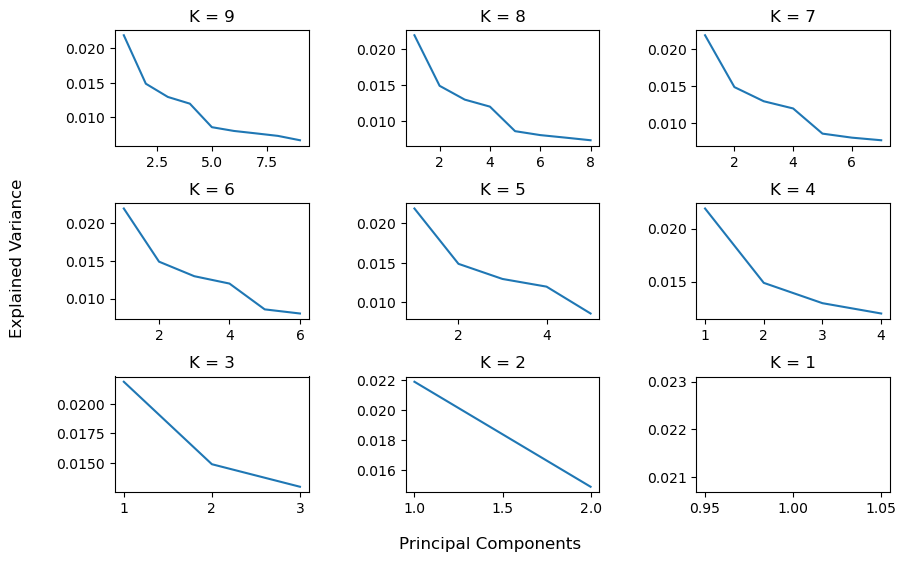

In [31]:
i = 0
fig, axs = plt.subplots(3,3,figsize=(10,6))
axs = axs.flatten()
for y in variances:
    x = range(1,len(y)+1)
    axs[i].plot(x, y)
    axs[i].set_title(f"K = {9-i}")
    i += 1

fig.supxlabel("Principal Components")
fig.supylabel("Explained Variance")
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

Based on the graph, the variance begins to stabilize and no longer changes significantly between \(k = 3\) and \(k = 4\), making these values the most suitable choices for the model.

### Fitting analysis
- Where does your model fit in the fitting graph? It appears that the model has been correctly trained, as the training and test results are nearly identical in this final attempt, both achieving an AUC of approximately 0.99.
- What are potential future improvements or next models? A potential improvement would be to further tune model parameters and make more extensive use of the available data. Given the time constraints of this project, we were unable to conduct a deeper analysis or thoroughly evaluate alternative models. Therefore, a key area for future improvement would be allowing more time for comprehensive experimentation and model development.
- How does dimensionality reduction affect your results compared to the full feature set? The dimensionality reduction component of the project suggests that the data may be relatively easy to classify; however, the unusually high performance could also indicate potential data leakage during training.

## Conclusion

## Statement of Collaboration
- David Moncivais: Coder and Writer: Coder during milestone 2 (created the word graph and described the dataset), fine tuning during milestone 3, and coder and writer for milestone 4.
- Mitchell Farrington: Data Explorer Writer: Found dataset to work with and did intro analysis for Milestone 1, created the Preprocessing plan for Milestone 2, Planner and evaluator for milestone 3 (based on results, I helped create the plan for how to proceed given the nature of the dataset), and developed the README and conclusion for Milestone 4.